# Univariate Zeitreihenanalyse — Gold (XAU/USD)

Dieses Notebook analysiert den Goldpreis (Ticker: `GC=F` von Yahoo Finance) im Zeitraum **2015 bis 2025**.

Wir folgen der klassischen **Box-Jenkins-Methodik**, die aus sieben Schritten besteht:

1. **Visuelle Inspektion** — Wie sieht die Zeitreihe aus? Gibt es einen Trend, Saisonalität, Ausreißer?
2. **Stationaritätstest (ADF-Test)** — Ist die Reihe stationär? Das ist eine Grundvoraussetzung für ARIMA.
3. **Differenzierung** — Falls nicht stationär: Reihe differenzieren, bis sie es ist.
4. **ACF & PACF** — Autokorrelation und partielle Autokorrelation analysieren, um die Modellordnung zu bestimmen.
5. **Modellauswahl (p, d, q)** — ARIMA-Parameter auf Basis der vorherigen Schritte wählen.
6. **Residualdiagnostik** — Sind die Residuen des Modells weißes Rauschen?
7. **Prognose** — Zukünftige Werte vorhersagen und Unsicherheitsintervalle berechnen.

Dieses Notebook deckt **alle sieben Schritte** für die Goldzeitreihe ab.

---
## Schritt 1: Visuelle Inspektion

Bevor wir irgendein statistisches Modell aufstellen, schauen wir uns die Zeitreihe zuerst mit eigenen Augen an. Das gibt uns ein erstes Gefühl dafür:

- Gibt es einen **langfristigen Trend** (steigt oder fällt der Preis über die Jahre)?
- Gibt es Phasen mit höherer oder niedrigerer **Volatilität** (breite vs. enge Schwankungen)?
- Gibt es **strukturelle Brüche** — also Zeitpunkte, an denen sich das Verhalten der Reihe plötzlich verändert hat (z.B. durch eine Krise, einen Krieg, eine Zentralbankentscheidung)?

Die visuelle Analyse ist kein optionaler Schritt — sie ist ein zentraler Teil der Box-Jenkins-Methodik.

In [1]:
import sys
import os

# Add project root to path so we can import from src/
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.utils.data_loader import load_series

In [2]:
# Load the Gold futures series (GC=F)
gold = load_series("GC=F")

[data_loader] Downloading GC=F from Yahoo Finance (2015-01-01 to 2025-05-04)...


[data_loader] Saved to: GC_F_2015-01-01_to_2025-05-04.csv


In [3]:
# Basic data overview: types, head, and summary statistics
print("=== Datentypen & Struktur ===")
gold.info()

print("\n=== Erste Zeilen ===")
display(gold.head())

print("\n=== Statistische Kennzahlen ===")
display(gold.describe())

=== Datentypen & Struktur ===
<class 'pandas.DataFrame'>
DatetimeIndex: 2597 entries, 2015-01-02 to 2025-05-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   2597 non-null   float64
 1   (High, GC=F)    2597 non-null   float64
 2   (Low, GC=F)     2597 non-null   float64
 3   (Open, GC=F)    2597 non-null   float64
 4   (Volume, GC=F)  2597 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 121.7 KB

=== Erste Zeilen ===


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2015-01-02,1186.000000,1194.500000,1169.500000,1184.000000,138
2015-01-05,1203.900024,1206.900024,1180.099976,1180.300049,470
2015-01-06,1219.300049,1220.000000,1203.500000,1203.500000,97
2015-01-07,1210.599976,1219.199951,1210.599976,1219.199951,29
2015-01-08,1208.400024,1215.699951,1206.300049,1207.000000,92



=== Statistische Kennzahlen ===


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
count,2597.000000,2597.000000,2597.000000,2597.000000,2597.000000
mean,1647.375779,1655.239046,1639.381171,1647.148093,5232.058144
std,456.709889,459.674481,453.397554,456.298615,28831.771889
min,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1266.099976,1270.800049,1260.300049,1266.400024,49.000000
50%,1600.000000,1621.000000,1579.800049,1594.500000,185.000000
75%,1898.599976,1907.699951,1886.099976,1897.300049,574.000000
max,3406.199951,3485.600098,3361.699951,3422.199951,386334.000000


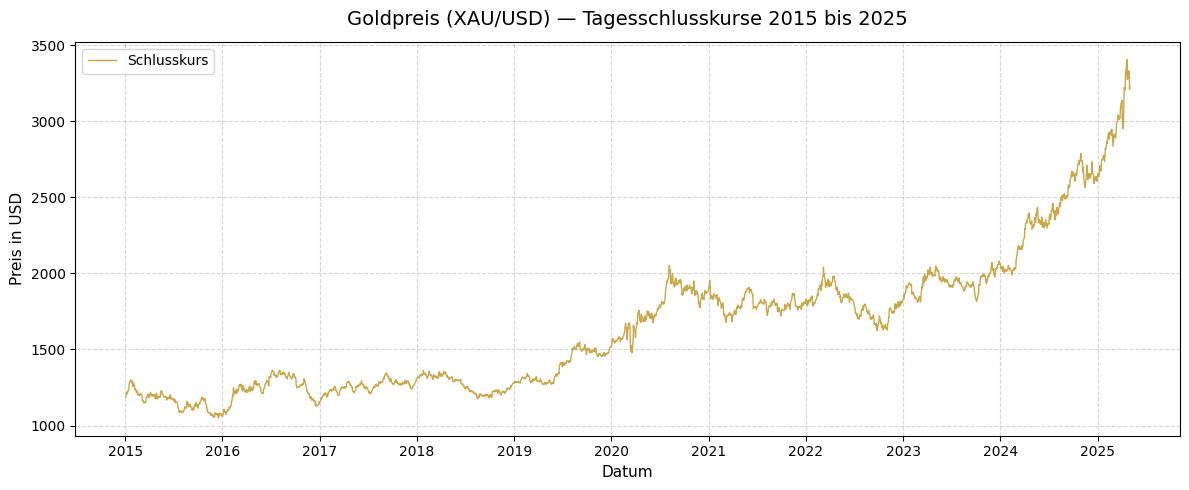

In [4]:
# Plot the daily closing price of Gold over the full sample period
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(gold.index, gold["Close"], color="#C9A84C", linewidth=1.0, label="Schlusskurs")

ax.set_title("Goldpreis (XAU/USD) — Tagesschlusskurse 2015 bis 2025", fontsize=14, pad=12)
ax.set_xlabel("Datum", fontsize=11)
ax.set_ylabel("Preis in USD", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

# Format x-axis with clean year labels
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## Erste Beobachtungen

_(Hier kommen Luis' Beobachtungen rein)_